In [68]:
import json
import os
import logging
import numpy as np
import requests
from PIL import Image
import scipy.stats
import matplotlib.pyplot as plt
import sys
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import pandas as pd
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)

import importlib
# check环境
print(sys.executable)
print(sys.version)

/nfs_beijing/kubeflow-user/yujie/.conda/envs/icey/bin/python
3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]


# 数据准备

In [49]:
data = pd.read_csv('../data/data_ai_r1_all_scaned.csv', index_col=0)
data.groupby('mut_num').apply(len)

mut_num
2    4064
3     262
4     147
5      65
dtype: int64

In [50]:
data['mut_posis'] = data['mt_aa_seq'].apply(lambda x: ['174', '175', '176', '177', '178', '355', '371'])
data['mut_posis_aa'] = data['mt_aa_seq'].apply(lambda x: [x[int(p)-1] 
                                                    for p in ['174', '175', '176', '177', '178', '355', '371']])

In [51]:
models = ['sequence_naturalness', 'structure_naturalness',  'stability', 'activity_v0(zero-shot)']

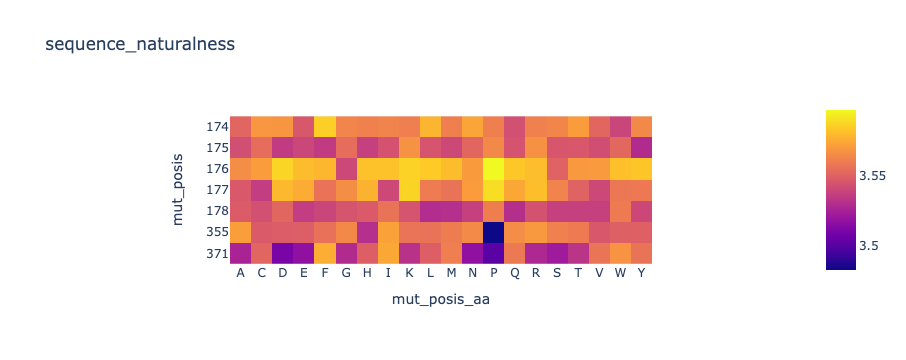

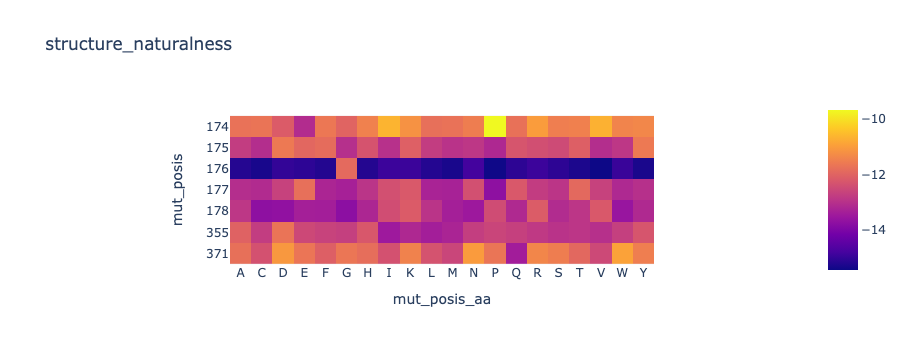

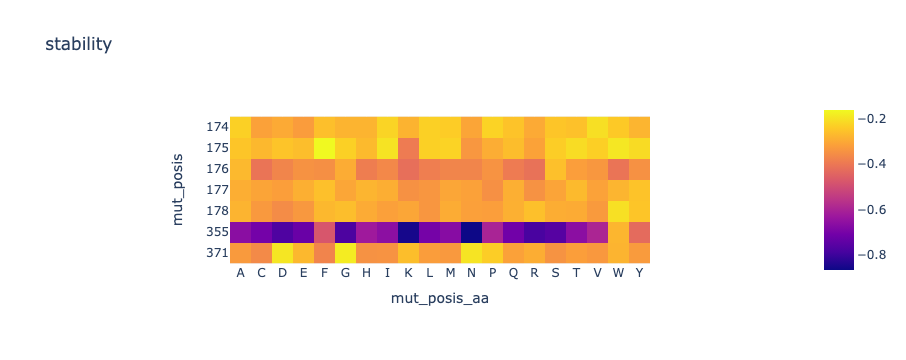

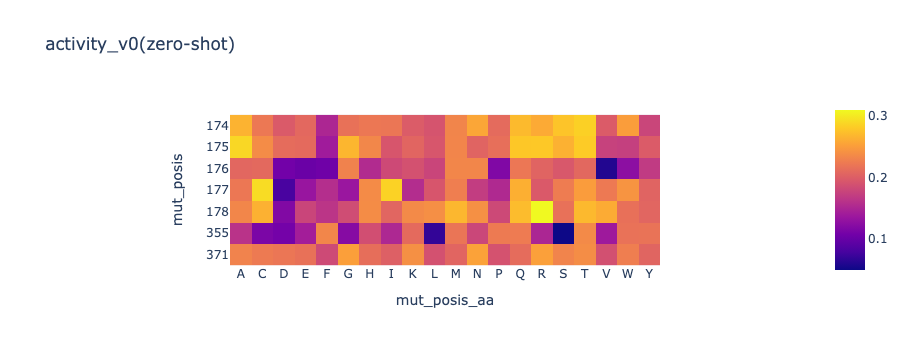

In [52]:
# crush points
def hotmap_by_posi_aa(data, m, aggfunc='mean', zmin=None, zmax=None):
    df = data.explode(['mut_posis','mut_posis_aa'])
    df_p = pd.pivot_table(df, columns='mut_posis_aa', index='mut_posis', values=m, aggfunc=aggfunc)
    if not zmin:
        zmin = df_p.min(axis=1).min()
    if not zmax:
        zmax = df_p.max(axis=1).max()
    fig = px.imshow(df_p
                   , width=600, title=m, zmin=zmin, zmax=zmax)
    fig.show()
for m in models:
    hotmap_by_posi_aa(data, m)

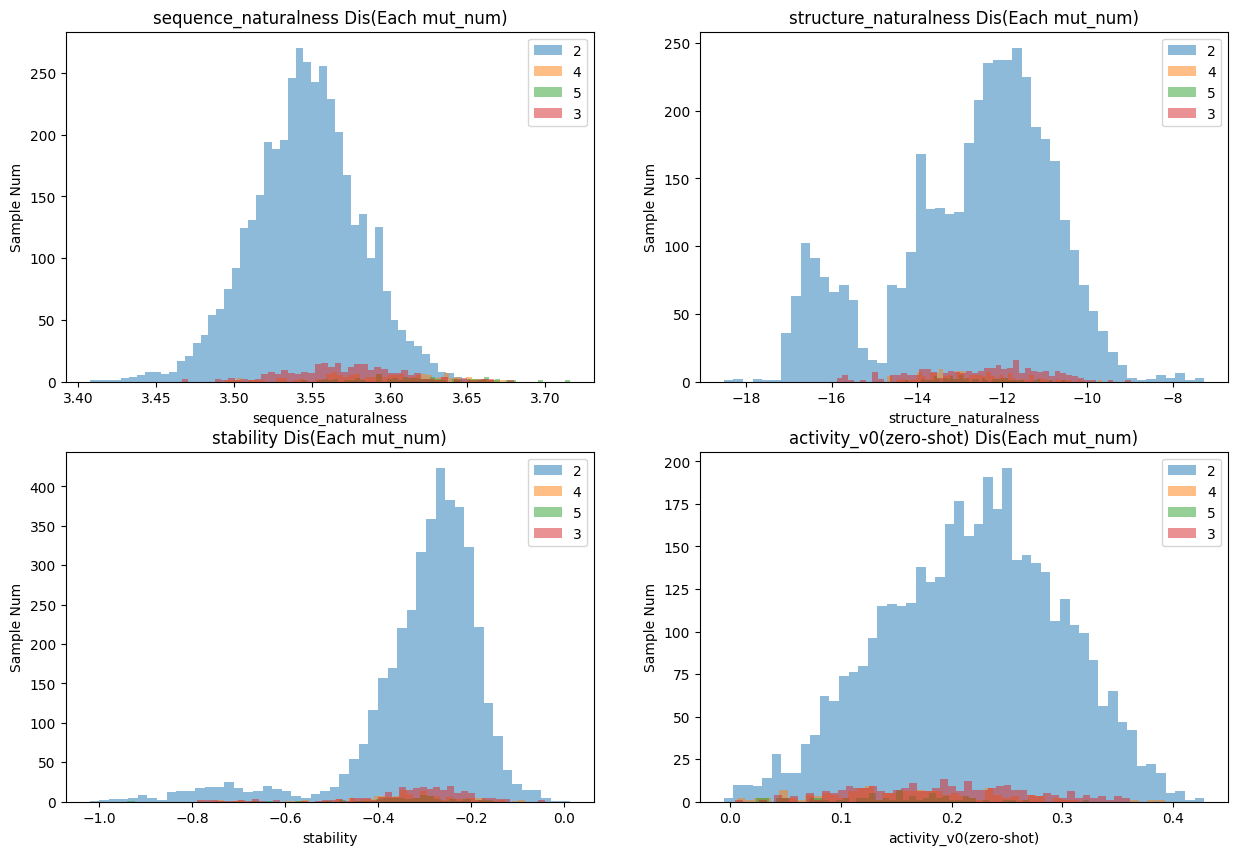

In [53]:
def hist_by_group(data, gc, histc, bars=50):
    gs = data[gc].drop_duplicates().to_list()
    for g in gs:
        plt.hist(data[data[gc]==g][histc], bars, alpha=0.5)
    plt.xlabel(histc)
    plt.ylabel('Sample Num')
    plt.title(f'{histc} Dis(Each {gc})')
    plt.legend(gs)

count = [1,2,3,4]
plt.figure(figsize=[15, 10])
for c, m in zip(count, models):
    plt.subplot(2, 2, c)
    hist_by_group(data, gc='mut_num', histc=m)

# 序列筛选

In [56]:
percentiles = [3.5585923047061447, -0.39208984375, -14.4332]
models = ['sequence_naturalness',  'stability', 'structure_naturalness']
leave = ['smaller', 'larger', 'larger']
data_now = data.copy()
print('raw',data_now.shape)
for p, m, l in zip(percentiles, models, leave):
    if l == 'smaller':
        data_now = data_now[data_now[m] < p]
        print(m, data_now.shape)
    else:
        data_now = data_now[data_now[m] > p]
        print(m, data_now.shape) 

raw (4538, 20)
sequence_naturalness (2753, 20)
stability (2491, 20)
structure_naturalness (2367, 20)


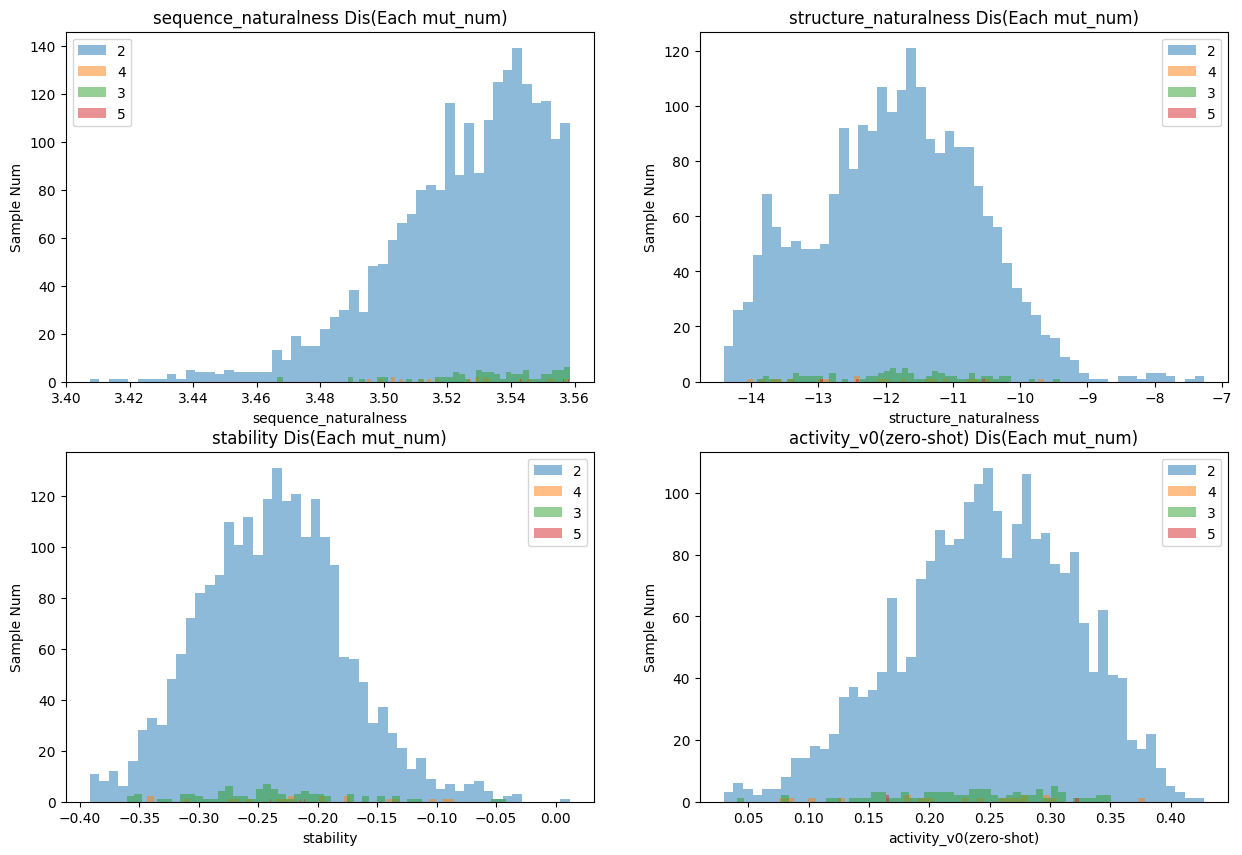

In [58]:
count = [1,2,3,4]
models = ['sequence_naturalness', 'structure_naturalness',  'stability', 'activity_v0(zero-shot)']
plt.figure(figsize=[15, 10])
for c, m in zip(count, models):
    plt.subplot(2, 2, c)
    hist_by_group(data_now, gc='mut_num', histc=m)

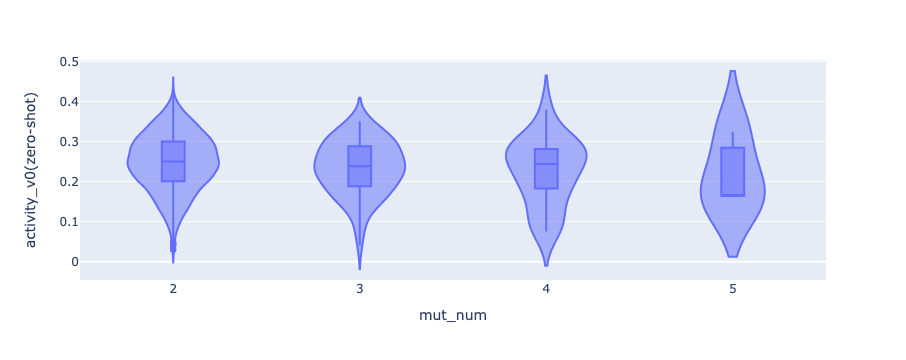

In [60]:
px.violin(data_now, x='mut_num', y='activity_v0(zero-shot)', box=True, width=600)

# 序列聚类

In [69]:
import torch
def get_embeddings(true_df, name):
    pred_df = pd.read_csv(f'../data/r1_activity_zero_shot_pred/{name}.pred.csv')
    merge_df = pd.merge(true_df, pred_df, on='unique_id')
    print(merge_df.shape)
    embed_list = []
    for index, row in tqdm(merge_df.iterrows()):
        mut_num = int(row['mut_num'])
        seqid = row['unique_id']
        embed_path = f'../data/r1_activity_zero_shot_pred/hidden_states/hidden_states-{seqid}.pt'
        model_embed = torch.load(embed_path,map_location=torch.device('cpu'))['hidden_states'].mean(0).numpy()
        embed_list.append(model_embed)
    print(len(embed_list))
    merge_df['embed'] = embed_list
    return merge_df
data_with_embed = get_embeddings(data_now, 'final_filtered_all')

(2291, 21)


/tmp/ipykernel_88097/356994874.py:11: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.

2291it [04:28,  8.55it/s]


2291


In [74]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

def embeding_cluster(X, n_clusters):
    # 创建 KMeans 模型并进行聚类
    kmeans = KMeans(n_clusters)
    kmeans.fit(X)
    
    # 获取聚类结果
    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_
    # print(labels)

    # 使用 t-SNE 进行降维
    tsne = TSNE(n_components=2)
    X_tsne = tsne.fit_transform(X)
    
    # 计算每个数据点到每个聚类中心的距离
    distances = np.zeros((len(X), len(centroids)))
    for i, point in enumerate(X):
        for j, center in enumerate(centroids):
            distances[i, j] = np.linalg.norm(point - center)
    return labels, centroids, distances, X_tsne[:, 0], X_tsne[:, 1]


def found_candidates(d, candidates_num):
    labels, _, distances, tsne1, tsne2 = embeding_cluster(np.array(d['embed'].to_list()), candidates_num)
    d['cluster'] = labels
    d['distance'] = [x[l] for x, l in zip(distances, labels)]
    d['tsne1'] = tsne1
    d['tsne2'] = tsne2
    best_dir = d.groupby('cluster').apply(lambda x: x['unique_id'].iloc[np.argmax(x['pred'])])
    d['candidates_tag'] = d.apply(lambda x: 1 if best_dir[x['cluster']]==x['unique_id'] else 0, axis=1)
    return d
    
## 分离不同突变点的数据
mut_config = {
    2: {'n_clusters': 30},
    3: {'n_clusters': 12},
    4: {'n_clusters': 8},
    5: {'n_clusters': 6}
}
print(1)
data_with_embed_taged = pd.DataFrame()
for mut_num, configs in mut_config.items():
    data_with_embed_taged = pd.concat([data_with_embed_taged, found_candidates(
        data_with_embed[data_with_embed['mut_num']==mut_num], configs['n_clusters']
    )])                                                       

1

In [79]:
data_with_embed_taged[data_with_embed_taged['candidates_tag']==1][
['unique_id',  'wt_aa_seq', 'wt_pdb_hash', 'mt_aa_seq',
       'mt_pdb_hash', 'pdb_mutation', 
       'mut_num', 'sequence_naturalness', 'structure_naturalness', 
       'label', 'stability', 'activity_v0(zero-shot)',
       'mut1', 'mut2',  'mut_posis', 'mut_posis_aa',
        'cluster', 'is_central',
       'tsne1', 'tsne2', 'candidates_tag', 'mut_id']
    ].to_csv('../data/candidates_ai_round1.csv')

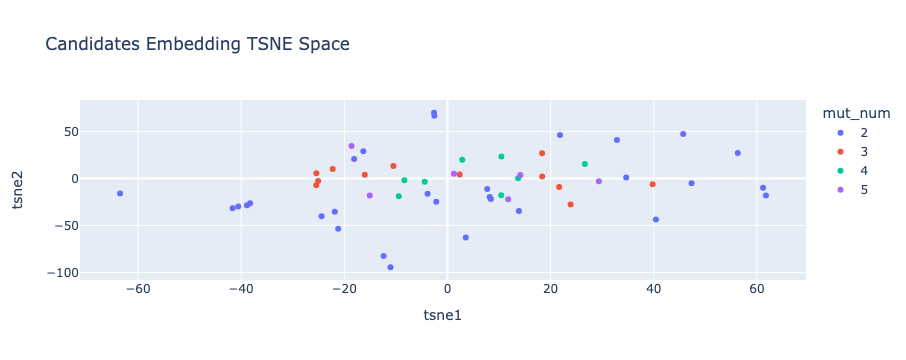

In [507]:
data_with_embed_taged['mut_num'] = data_with_embed_taged['mut_num'].astype(str)
px.scatter(data_with_embed_taged[data_with_embed_taged['candidates_tag']==1], x='tsne1', y='tsne2', color='mut_num',
          width=500, title='Candidates Embedding TSNE Space')

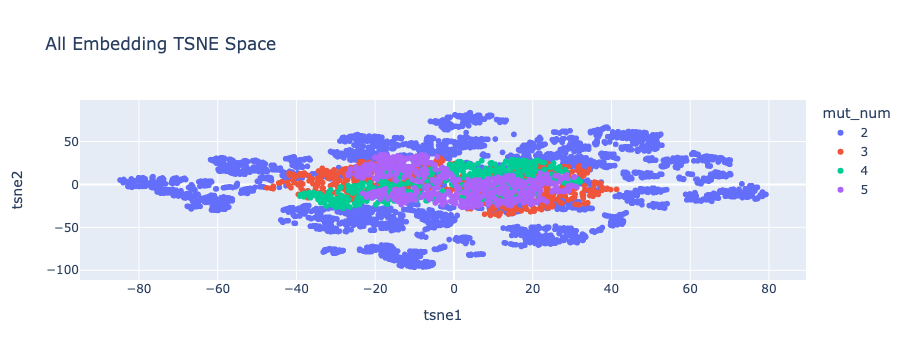

In [508]:
px.scatter(data_with_embed_taged, x='tsne1', y='tsne2', color='mut_num',
          width=500, title='All Embedding TSNE Space')

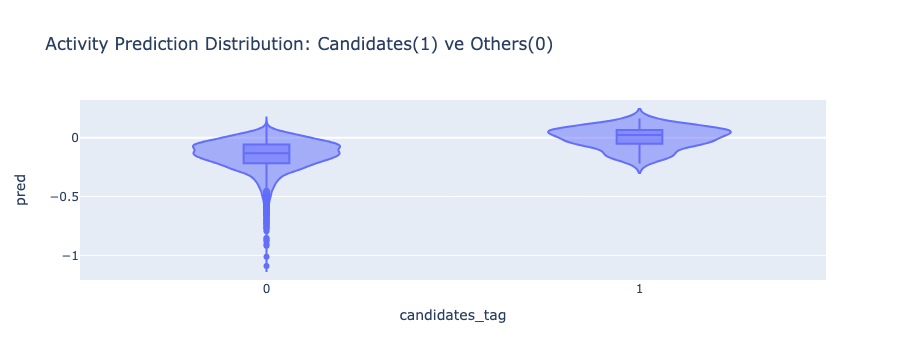

In [511]:
px.violin(data_with_embed_taged, x='candidates_tag', y='pred', box=True, width=700,
         title='Activity Prediction Distribution: Candidates(1) ve Others(0)')

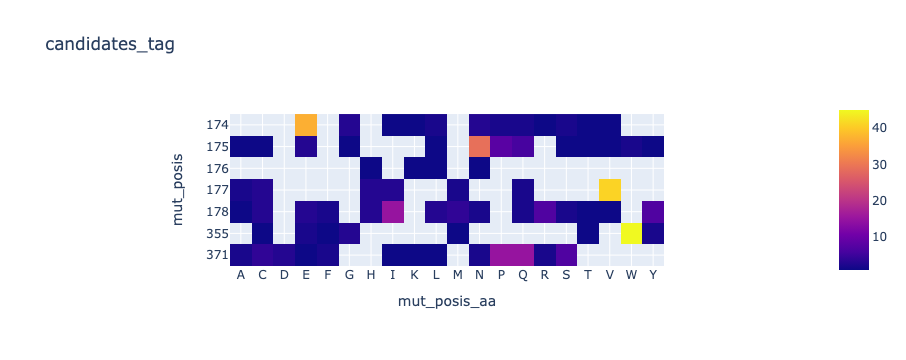

In [546]:
hotmap_by_posi_aa(data_with_embed_taged[data_with_embed_taged['candidates_tag']==1], 'candidates_tag', 
                  aggfunc=lambda x: len(x) if len(x) < 50 else None)